# Phase 2 — Build the First ML Model

**Goal:** Train two models, evaluate them honestly, and understand the results.

**What we'll do:**
1. Load the clean data from Phase 1
2. Split into train set (80%) and test set (20%)
3. Train Model 1 — Logistic Regression (simple baseline)
4. Evaluate — accuracy, precision, recall, F1
5. Train Model 2 — Random Forest (stronger model)
6. Compare both models and pick the winner

**Rule:** Run one cell at a time. Read every number in the output. Don't skip ahead.

## Step 1 — Load the Clean Data

We load the file we saved in Checkpoint 4 — already cleaned, all numbers, ready to use.
We also separate the data into:
- **X** = input columns (everything the model uses to make a prediction)
- **y** = target column (what we're trying to predict: Churn 0 or 1)

In [1]:
import pandas as pd

# Load the clean file from Phase 1
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

# X = all columns EXCEPT Churn — these are the inputs (features)
# y = only the Churn column — this is what we predict (target)
X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"X shape: {X.shape}  ← {X.shape[0]} customers, {X.shape[1]} features")
print(f"y shape: {y.shape}  ← one label (0 or 1) per customer")
print(f"\nChurn distribution in y:")
print(y.value_counts())

X shape: (7032, 30)  ← 7032 customers, 30 features
y shape: (7032,)  ← one label (0 or 1) per customer

Churn distribution in y:
Churn
0    5163
1    1869
Name: count, dtype: int64


## Step 2 — Split into Train and Test Sets

We split the data into two parts:
- **Train set (80%)** — the model studies this. It sees both the inputs AND the correct answers.
- **Test set (20%)** — we hide this until evaluation. The model has never seen it.

Why? Because if we test on the same data we trained on, the model would just memorize the answers — like knowing the exam questions in advance. We need to test on NEW data to know if it actually learned something.

`random_state=42` just means: shuffle the data the same way every time so our results are reproducible.

In [2]:
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% test
# stratify=y means: keep the same 74/26 churn ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} customers")
print(f"Test set     : {X_test.shape[0]} customers")
print(f"\nChurn % in train : {y_train.mean()*100:.1f}%")
print(f"Churn % in test  : {y_test.mean()*100:.1f}%")
print("\n(Both should be ~26.5% — that's what stratify=y ensures)")

Training set : 5625 customers
Test set     : 1407 customers

Churn % in train : 26.6%
Churn % in test  : 26.6%

(Both should be ~26.5% — that's what stratify=y ensures)


## Step 3 — Train Model 1: Logistic Regression

**What is Logistic Regression?**

Despite the name, it's a **classification** model (yes/no prediction), not regression.

Imagine drawing a straight line that separates churners from non-churners. Logistic Regression finds the best possible line through all 30 columns at once. For each customer, it gives a probability between 0 and 1 — "this customer has a 78% chance of churning."

We use `class_weight="balanced"` to handle our imbalanced dataset — it tells the model: "pay more attention when you miss a churner, because that mistake is more costly."

In [7]:
from sklearn.linear_model import LogisticRegression

# Create the model
# class_weight="balanced" = penalise missing churners more (handles imbalance)
# max_iter=1000 = give it enough attempts to find the best line
lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

# Train — model studies the training data
lr_model.fit(X_train, y_train)

# Predict — model guesses churn (0 or 1) for each customer in the test set
lr_preds = lr_model.predict(X_test)

print("Logistic Regression trained ✅")
print(f"Test set predictions — first 10: {lr_preds[:10]}")
print(f"Actual labels        — first 10: {y_test.values[:10]}")

Logistic Regression trained ✅
Test set predictions — first 10: [0 1 0 0 0 1 0 0 1 0]
Actual labels        — first 10: [0 0 0 1 0 1 0 0 1 0]


C:\Users\ashishm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 4 — Evaluate Model 1

**4 metrics we use (memorise these for interviews):**

| Metric | Plain English |
|--------|--------------|
| **Accuracy** | Out of all customers, what % did we predict correctly? |
| **Precision** | Of all customers we flagged as "will churn", what % actually did? |
| **Recall** | Of all customers who actually churned, what % did we catch? |
| **F1 Score** | Balance between precision and recall (one combined score) |

**For churn, Recall is the most important.** Missing a churner = losing a customer = revenue loss.

**Confusion Matrix** — a table showing 4 types of predictions:
- **True Positive (TP):** Predicted churn, actually churned ✅
- **True Negative (TN):** Predicted stayed, actually stayed ✅
- **False Positive (FP):** Predicted churn, actually stayed ❌ (sent unnecessary discount)
- **False Negative (FN):** Predicted stayed, actually churned ❌ (lost the customer!)

=== Logistic Regression Results ===
Accuracy  : 72.71%
Precision : 49.17%
Recall    : 79.68%  ← most important for churn
F1 Score  : 60.82%


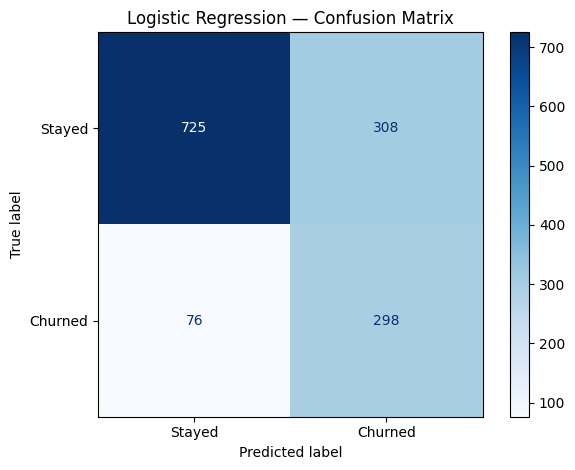

In [4]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Calculate the 4 metrics
lr_accuracy  = accuracy_score(y_test, lr_preds)
lr_precision = precision_score(y_test, lr_preds)
lr_recall    = recall_score(y_test, lr_preds)
lr_f1        = f1_score(y_test, lr_preds)

print("=== Logistic Regression Results ===")
print(f"Accuracy  : {lr_accuracy:.2%}")
print(f"Precision : {lr_precision:.2%}")
print(f"Recall    : {lr_recall:.2%}  ← most important for churn")
print(f"F1 Score  : {lr_f1:.2%}")

# Draw confusion matrix
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

# LOOK AT THE CONFUSION MATRIX:
# Top-left  = correctly predicted "Stayed" (True Negative)
# Top-right = predicted "Churned" but actually Stayed (False Positive)
# Bottom-left  = predicted "Stayed" but actually Churned (False Negative) ← BAD
# Bottom-right = correctly predicted "Churned" (True Positive) ← GOOD

## Step 5 — Train Model 2: Random Forest

**What is a Random Forest?**

Imagine asking 100 different people "will this customer churn?" and taking a vote.

Each person looks at a random subset of the data and the features. Each person is a **decision tree** — a series of yes/no questions like: "Is their contract month-to-month? → Yes → Is their tenure less than 12 months? → Yes → Likely churner."

100 trees vote. Majority wins. That's a Random Forest.

It's almost always stronger than Logistic Regression because it can catch complex patterns that a single line cannot.

=== Random Forest Results ===
Accuracy  : 78.89%
Precision : 63.32%
Recall    : 48.93%  ← most important for churn
F1 Score  : 55.20%


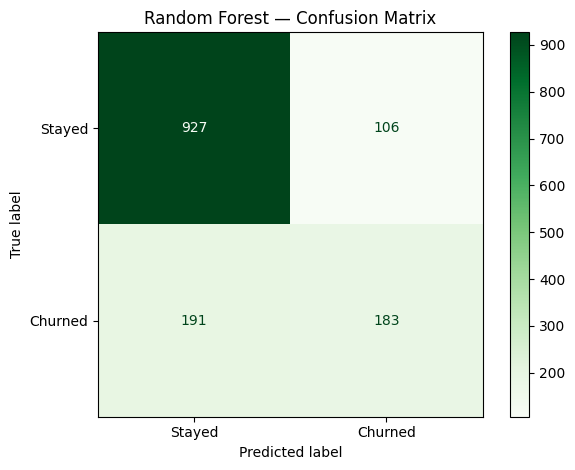

In [5]:
from sklearn.ensemble import RandomForestClassifier

# 100 trees, balanced class weights to handle imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_accuracy  = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall    = recall_score(y_test, rf_preds)
rf_f1        = f1_score(y_test, rf_preds)

print("=== Random Forest Results ===")
print(f"Accuracy  : {rf_accuracy:.2%}")
print(f"Precision : {rf_precision:.2%}")
print(f"Recall    : {rf_recall:.2%}  ← most important for churn")
print(f"F1 Score  : {rf_f1:.2%}")

# Confusion matrix
cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Stayed", "Churned"])
disp_rf.plot(cmap="Greens")
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

In [6]:
# Side by side comparison of both models
comparison = pd.DataFrame({
    "Metric"             : ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": [f"{lr_accuracy:.2%}", f"{lr_precision:.2%}",
                            f"{lr_recall:.2%}", f"{lr_f1:.2%}"],
    "Random Forest"      : [f"{rf_accuracy:.2%}", f"{rf_precision:.2%}",
                            f"{rf_recall:.2%}", f"{rf_f1:.2%}"]
})

print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))
print("\n★ Winner for churn prediction = model with higher Recall")

=== MODEL COMPARISON ===
   Metric Logistic Regression Random Forest
 Accuracy              72.71%        78.89%
Precision              49.17%        63.32%
   Recall              79.68%        48.93%
 F1 Score              60.82%        55.20%

★ Winner for churn prediction = model with higher Recall


## Your Observations — Fill This In

**Q1: What was the Recall score for Logistic Regression? What does that number mean in plain English?**
79.68% , it means if model predicts yes , how many were actual correct

**Q2: What was the Recall score for Random Forest? Is it better or worse than Logistic Regression?**
48.93%

**Q3: Look at the confusion matrix for Logistic Regression. How many churners did the model MISS (bottom-left number)? What is that called?**
76 , it is called recall

**Q4: Why did we use class_weight="balanced" in both models?**
to handle imbalance dataset

**Q5: Which model would you pick for this business problem and why?**
logistic regression because it has better recall score

---
Paste your answers in the chat when done.
After this, we push to GitHub and then start Phase 3 — improving the model further.